📡 Step 1: Loading & Cleaning Patient EEG...
🧠 Step 2: Initializing Architecture & Brain Transplant...
🔍 Step 3: Auditing 'Deactivation' Signal (-0.1158)...
🎨 Step 4: Rendering Clinical Master Visuals...


/tmp/ipykernel_2703/329259551.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


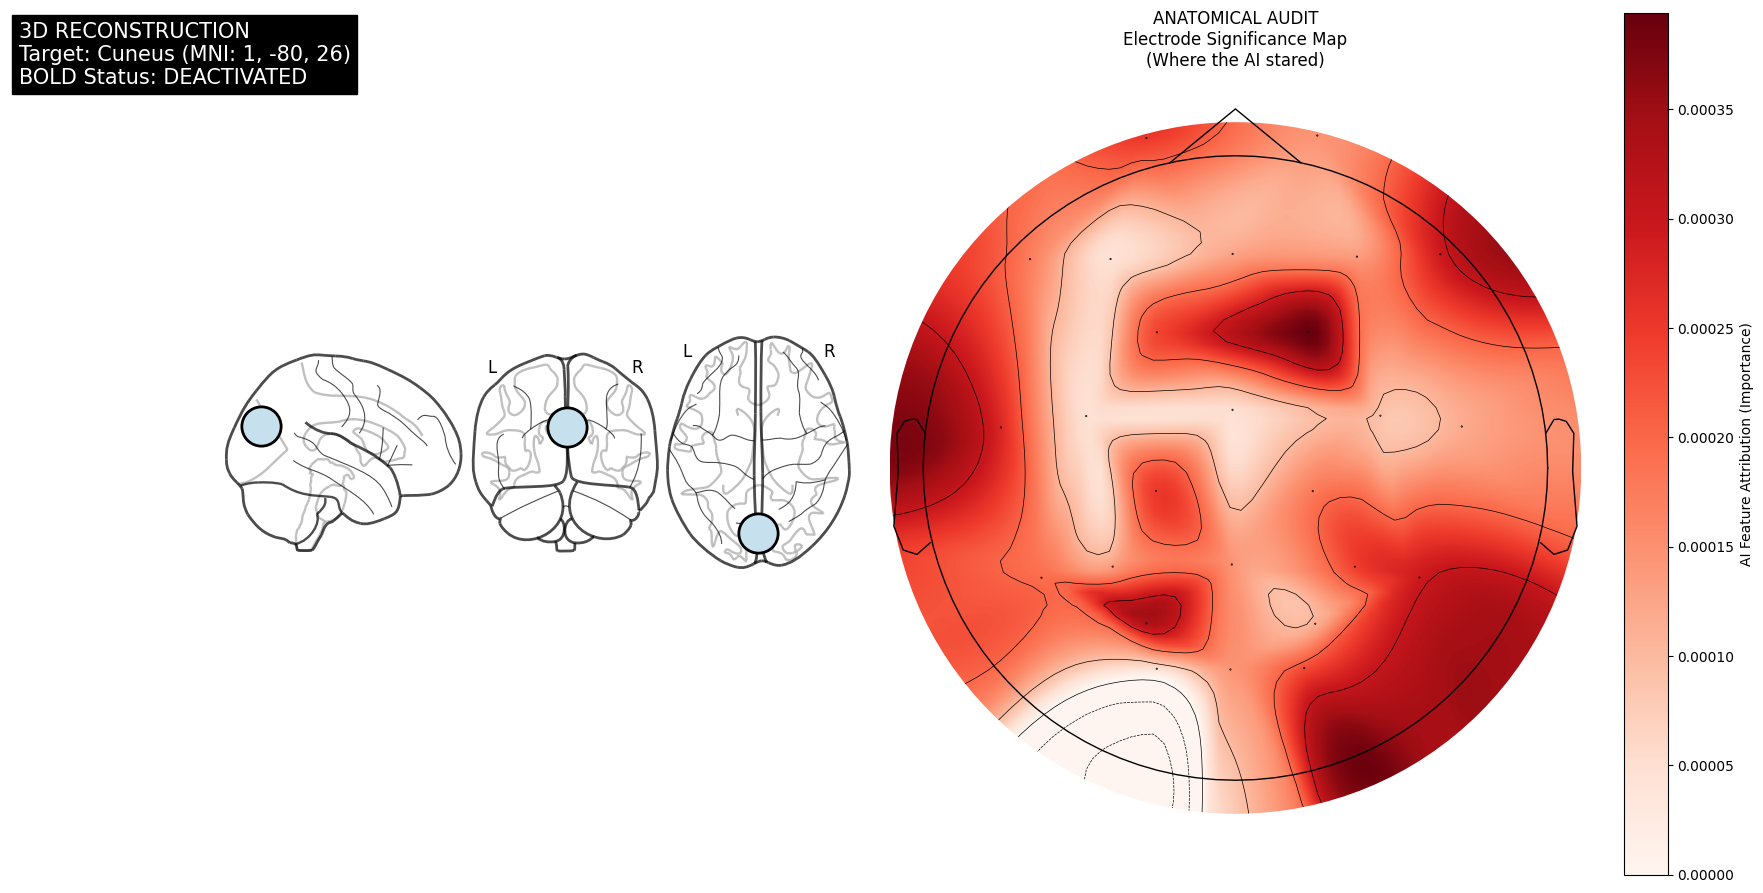

✅ Master Dashboard Complete. Ready for Paris!


In [26]:
# --- THE PARIS MASTER DASHBOARD: END-TO-END CLINICAL AUDIT ---
import os
import sys
import torch
import mne
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from nilearn import plotting
from captum.attr import IntegratedGradients
from einops import rearrange
from huggingface_hub import hf_hub_download

# --- CONFIGURATION & PATHS ---
EEG_CHANNELS = 26
TIME_STEPS = 3200
PATCH_SIZE = 200
PATCHES = 16
ROI_COUNT = 1
REPO_PATH = os.path.abspath('./NeuroBOLT')
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

from models.model import NeuroBOLTransformer

print("📡 Step 1: Loading & Cleaning Patient EEG...")
# Download real PhysioNet data
raw_fnames = mne.datasets.eegbci.load_data(1, [1])
raw = mne.io.read_raw_edf(raw_fnames[0], preload=True, verbose=False)

# The "Clinician's Scrub": Fix names for MNE 10-20 dictionary
cleaned_names = {ch: ch.strip('.').upper().replace('Z', 'z').replace('FP', 'Fp') for ch in raw.ch_names}
raw.rename_channels(cleaned_names)

# Selective Whole-Head Montage (Frontal to Occipital)
whole_head_26 = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 
    'FC1', 'FC2', 'T7', 'C3', 'Cz', 'C4', 'T8', 
    'CP1', 'CP2', 'P7', 'P3', 'Pz', 'P4', 'P8', 
    'PO3', 'PO4', 'O1', 'Oz', 'O2'
]
raw_26 = raw.copy().pick(whole_head_26)
data_26, _ = raw_26[:, :TIME_STEPS]

# Standardize and format for Transformer (1, 26, 16, 200)
eeg_tensor = torch.tensor(data_26, dtype=torch.float32)
eeg_input = ((eeg_tensor - eeg_tensor.mean()) / eeg_tensor.std()).view(1, EEG_CHANNELS, PATCHES, PATCH_SIZE)
eeg_input.requires_grad_()
input_chans = torch.arange(EEG_CHANNELS + 1) # Bypass for CLS + 26 channels

print("🧠 Step 2: Initializing Architecture & Brain Transplant...")
model = NeuroBOLTransformer(
    EEG_length=TIME_STEPS, EEG_channel=EEG_CHANNELS,
    patch_size=PATCH_SIZE, num_roi=ROI_COUNT, init_values=0.0
)

# Download and inject trained Cuneus weights
checkpoint_path = hf_hub_download(repo_id="ssssssup/NeuroBOLT", filename="checkpoints/Cuneus.pth")
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
state_dict = checkpoint.get('model_state_dict', checkpoint.get('model', checkpoint))
model.load_state_dict(state_dict, strict=False)
model.eval()

with torch.no_grad():
    prediction = model(eeg_input, input_chans=input_chans)
    pred_val = prediction[0, 0].item()

print(f"🔍 Step 3: Auditing 'Deactivation' Signal ({pred_val:.4f})...")
ig = IntegratedGradients(model)
# internal_batch_size=1 prevents the tensor mismatch error
attr = ig.attribute(
    inputs=eeg_input, target=0, 
    additional_forward_args=(input_chans,), 
    n_steps=10, internal_batch_size=1
)
attr_data = rearrange(attr.squeeze(0).detach(), 'c p s -> c (p s)').numpy()

print("🎨 Step 4: Rendering Clinical Master Visuals...")
fig = plt.figure(figsize=(18, 9))

# --- LEFT: The 3D Anatomical Reconstruction ---
ax1 = fig.add_subplot(1, 2, 1)
# Red-Blue scale: Red=Activation, Blue=Deactivation
cmap_3d = mpl.colormaps['RdBu_r']
norm_3d = mpl.colors.Normalize(vmin=-0.5, vmax=0.5)
color_3d = cmap_3d(norm_3d(pred_val))

display = plotting.plot_glass_brain(
    None, display_mode='ortho', figure=fig, axes=ax1,
    title=f"3D RECONSTRUCTION\nTarget: Cuneus (MNI: 1, -80, 26)\nBOLD Status: {'DEACTIVATED' if pred_val < 0 else 'ACTIVATED'}"
)
display.add_markers(
    marker_coords=[[1, -80, 26]], marker_color=[color_3d], 
    marker_size=800, edgecolor='black', linewidth=2
)

# --- RIGHT: The Topographic Audit ---
ax2 = fig.add_subplot(1, 2, 2)
info = mne.create_info(ch_names=raw_26.ch_names, sfreq=200, ch_types='eeg')
info.set_montage('standard_1020')
# Mean attribution across time to show spatial importance
channel_importance = np.mean(np.abs(attr_data), axis=1)
im, _ = mne.viz.plot_topomap(channel_importance, info, axes=ax2, show=False, cmap='Reds')
plt.colorbar(im, ax=ax2, label='AI Feature Attribution (Importance)')
ax2.set_title("ANATOMICAL AUDIT\nElectrode Significance Map\n(Where the AI stared)")

plt.tight_layout()
plt.show()
print("✅ Master Dashboard Complete. Ready for Paris!")

In [27]:
# --- SAVE FOR PRESENTATION ---
save_path = "NeuroBOLT_Audit_Paris.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"🚀 High-res slide saved as: {save_path}")

🚀 High-res slide saved as: NeuroBOLT_Audit_Paris.png
